# MNIST LeNet-5 CertCF Metrics

Dedicated analysis of the 1,000 MNIST source→target tasks produced by `mnist_certcf_lenet5.yaml`. Paper-compatible metrics, image-specific diagnostics, and CertCF implementation diagnostics are kept in separate sections. Expensive computations are fingerprinted and cached under `results/mnist_metrics_cache/`.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
for path in (ROOT, ROOT / 'src'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from counterfactuals.benchmarks import create_default_registries
from counterfactuals.utils.config import read_yaml
from notebooks.utils.io import feature_columns, load_result
from notebooks.utils.mnist import (
    MNIST_N_PIXELS,
    add_mnist_pixel_metrics,
    attach_target_confidence,
    cache_fingerprint,
    clustered_metric_summary,
    embedding_lof_scores,
    evaluate_mnist_robustness,
    extract_lenet5_embeddings,
    load_or_compute_dataframe,
    mnist_pair_metric_table,
    mnist_task_coverage_table,
    neighborhood_label_metrics,
    relative_proximity_summary,
    robustness_curve_summary,
    same_class_distribution_summary,
    same_class_neighbor_metrics,
    validate_mnist_benchmark_df,
)
from notebooks.utils.style import setup_notebook_style
from scripts.benchmark import _build_mnist_model_from_checkpoint

setup_notebook_style()
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

RESULT_PATH = ROOT / 'results' / 'mnist_certcf_lenet5.parquet'
CONFIG_PATH = ROOT / 'configs' / 'benchmarks' / 'mnist_certcf_lenet5.yaml'
CACHE_DIR = ROOT / 'results' / 'mnist_metrics_cache'
EXPORT_DIR = ROOT / 'results' / 'mnist_metrics'
EXPORT_OUTPUTS = False
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
ROBUSTNESS_LEVELS = [0.00, 0.01, 0.03, 0.05, 0.10, 0.20]
ROBUSTNESS_SAMPLES = 64
BOOTSTRAP_RESAMPLES = 10_000
ANALYSIS_VERSION = 1
FIGURES = {}
print({'root': str(ROOT), 'device': DEVICE, 'cache': str(CACHE_DIR)})

{'root': '/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling', 'device': 'cuda', 'cache': '/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/mnist_metrics_cache'}


## 1. Run audit

A task is identified by `(query_idx, source_class, target_class)`. The same source image may occur with several targets, so `query_idx` is also the bootstrap cluster.

,value
n_tasks,1.000000e+03
n_source_images,1.200000e+02
n_source_classes,1.000000e+01
n_target_classes,1.000000e+01
n_success,1.000000e+03
validity_pct,1.000000e+02
y_true_source_mismatches,0.000000e+00
target_prediction_mismatches,0.000000e+00
tasks_per_source_min,7.000000e+00
tasks_per_source_max,9.000000e+00


target_class,0,1,2,3,4,5,6,7,8,9
source_class,,,,,,,,,,
0,0,11,12,10,12,11,10,12,11,11
1,11,0,11,12,10,12,12,12,11,9
2,12,12,0,10,11,11,11,11,11,11
3,10,11,12,0,11,10,11,12,11,12
4,11,12,11,11,0,11,10,12,11,11
5,11,11,12,12,12,0,8,11,12,11
6,12,12,10,10,11,12,0,11,10,12
7,12,9,11,10,11,11,12,0,12,12
8,12,11,10,12,12,11,11,12,0,9


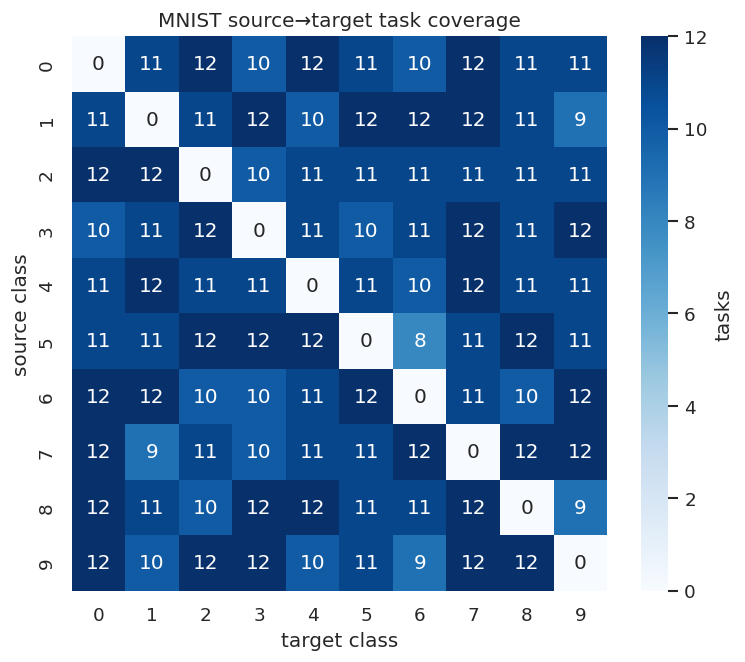

In [2]:
if not RESULT_PATH.exists():
    raise FileNotFoundError(f'Missing benchmark result: {RESULT_PATH}')
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f'Missing benchmark config: {CONFIG_PATH}')

CONFIG = read_yaml(CONFIG_PATH)
EXPECTED_TASKS = int(CONFIG['sampling']['n_queries'])
BENCHMARK_DF = load_result(
    RESULT_PATH,
    method_labels={'certcf_lenet5': 'CertCF LeNet-5'},
)
AUDIT = validate_mnist_benchmark_df(BENCHMARK_DF, expected_tasks=EXPECTED_TASKS)
COVERAGE_DF = mnist_task_coverage_table(BENCHMARK_DF)
TASKS_PER_SOURCE = BENCHMARK_DF.groupby('query_idx').size()

x_orig_cols, x_cf_cols = feature_columns(BENCHMARK_DF)
if len(x_orig_cols) != MNIST_N_PIXELS or len(x_cf_cols) != MNIST_N_PIXELS:
    raise ValueError('Expected exactly 784 original and 784 counterfactual pixel columns.')
X_ORIG = BENCHMARK_DF[x_orig_cols].to_numpy(dtype=np.float32)
X_CF_RAW = BENCHMARK_DF[x_cf_cols].to_numpy(dtype=np.float32)
X_CF = np.clip(X_CF_RAW, 0.0, 1.0)
TARGETS = BENCHMARK_DF['target_class'].to_numpy(dtype=np.int64)

AUDIT_DF = pd.DataFrame([{
    **AUDIT,
    'tasks_per_source_min': int(TASKS_PER_SOURCE.min()),
    'tasks_per_source_max': int(TASKS_PER_SOURCE.max()),
    'cf_raw_min': float(X_CF_RAW.min()),
    'cf_raw_max': float(X_CF_RAW.max()),
    'pixels_outside_bounds_raw': int(((X_CF_RAW < 0) | (X_CF_RAW > 1)).sum()),
    'pixels_outside_bounds_tol_1e-6': int(((X_CF_RAW < -1e-6) | (X_CF_RAW > 1 + 1e-6)).sum()),
}])
display(AUDIT_DF.T.rename(columns={0: 'value'}))
display(COVERAGE_DF)

fig, ax = plt.subplots(figsize=(7.2, 6.0))
sns.heatmap(COVERAGE_DF, annot=True, fmt='g', cmap='Blues', cbar_kws={'label': 'tasks'}, ax=ax)
ax.set_title('MNIST source→target task coverage')
ax.set_xlabel('target class')
ax.set_ylabel('source class')
FIGURES['task_coverage'] = fig
plt.show()

In [3]:
registries = create_default_registries()
MNIST_DATASET = registries['dataset'].create('mnist', data_dir=str(ROOT / 'data'))
MNIST_DATASET.load()
X_TRAIN, Y_TRAIN = MNIST_DATASET.get_train()
X_TEST, Y_TEST = MNIST_DATASET.get_test()

MODEL_PARAMS = dict(CONFIG['model']['params'])
CHECKPOINT_PATH = Path(MODEL_PARAMS['checkpoint'])
if not CHECKPOINT_PATH.is_absolute():
    CHECKPOINT_PATH = ROOT / CHECKPOINT_PATH
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f'Missing LeNet-5 checkpoint: {CHECKPOINT_PATH}')
MODEL = _build_mnist_model_from_checkpoint(
    checkpoint=str(CHECKPOINT_PATH),
    device=DEVICE,
    architecture=MODEL_PARAMS.get('architecture', 'lenet5'),
    num_classes=int(MODEL_PARAMS.get('num_classes', 10)),
)

BASE_FINGERPRINT = cache_fingerprint(
    [RESULT_PATH, CONFIG_PATH, CHECKPOINT_PATH],
    settings={'analysis_version': ANALYSIS_VERSION, 'train_size': len(X_TRAIN)},
)
print({'train': X_TRAIN.shape, 'test': X_TEST.shape, 'checkpoint': str(CHECKPOINT_PATH)})

{'train': (55000, 784), 'test': (10000, 784), 'checkpoint': '/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/checkpoints/mnist_lenet5_classifier/best.ckpt'}


## 2. Model embeddings, accuracy, and confidence

The image-specific representation is the 84-dimensional activation after LeNet-5's second fully connected ReLU and immediately before its final classifier. It is a classifier-dependent diagnostic, not an independent perceptual metric.

In [4]:
def embedding_frame(x, labels):
    z = extract_lenet5_embeddings(MODEL, x, batch_size=1024)
    return pd.DataFrame({
        'label': np.asarray(labels, dtype=np.int64),
        **{f'z_{idx}': z[:, idx] for idx in range(z.shape[1])},
    })

TRAIN_EMBEDDING_DF, train_embedding_cache_hit = load_or_compute_dataframe(
    CACHE_DIR / 'train_embeddings.parquet',
    cache_fingerprint([CHECKPOINT_PATH], settings={'split': 'train55k', 'version': ANALYSIS_VERSION}),
    lambda: embedding_frame(X_TRAIN, Y_TRAIN),
)
TEST_EMBEDDING_DF, test_embedding_cache_hit = load_or_compute_dataframe(
    CACHE_DIR / 'test_embeddings.parquet',
    cache_fingerprint([CHECKPOINT_PATH], settings={'split': 'test10k', 'version': ANALYSIS_VERSION}),
    lambda: embedding_frame(X_TEST, Y_TEST),
)
CF_EMBEDDING_DF, cf_embedding_cache_hit = load_or_compute_dataframe(
    CACHE_DIR / 'cf_embeddings.parquet',
    cache_fingerprint([RESULT_PATH, CHECKPOINT_PATH], settings={'split': 'counterfactuals', 'clip': True, 'version': ANALYSIS_VERSION}),
    lambda: embedding_frame(X_CF, TARGETS),
)
Z_COLS = [f'z_{idx}' for idx in range(84)]
Z_TRAIN = TRAIN_EMBEDDING_DF[Z_COLS].to_numpy(dtype=np.float32)
Z_TEST = TEST_EMBEDDING_DF[Z_COLS].to_numpy(dtype=np.float32)
Z_CF = CF_EMBEDDING_DF[Z_COLS].to_numpy(dtype=np.float32)

BACKBONE = MODEL.model.model if hasattr(MODEL.model, 'model') else MODEL.model
FINAL_LINEAR = BACKBONE.classifier[-1]
FINAL_WEIGHT = FINAL_LINEAR.weight.detach().cpu().numpy()
FINAL_BIAS = FINAL_LINEAR.bias.detach().cpu().numpy()
logits_from_embeddings = lambda z: z @ FINAL_WEIGHT.T + FINAL_BIAS
TRAIN_LOGITS = logits_from_embeddings(Z_TRAIN)
TEST_LOGITS = logits_from_embeddings(Z_TEST)
CF_LOGITS = logits_from_embeddings(Z_CF)

MODEL_AUDIT_DF = pd.DataFrame([{
    'train_accuracy_pct': 100.0 * np.mean(TRAIN_LOGITS.argmax(axis=1) == Y_TRAIN),
    'test_accuracy_pct': 100.0 * np.mean(TEST_LOGITS.argmax(axis=1) == Y_TEST),
    'cf_target_accuracy_after_clip_pct': 100.0 * np.mean(CF_LOGITS.argmax(axis=1) == TARGETS),
    'embedding_dim': Z_TRAIN.shape[1],
}])
CACHE_STATUS_DF = pd.DataFrame([{
    'train_embeddings': train_embedding_cache_hit,
    'test_embeddings': test_embedding_cache_hit,
    'cf_embeddings': cf_embedding_cache_hit,
}]).rename(index={0: 'cache_hit'})
display(MODEL_AUDIT_DF.round(4))
display(CACHE_STATUS_DF)

,train_accuracy_pct,test_accuracy_pct,cf_target_accuracy_after_clip_pct,embedding_dim
0,99.5236,99.03,100.0,84


,train_embeddings,test_embeddings,cf_embeddings
cache_hit,True,True,True


## 3. Paper-compatible core metrics

Stored benchmark distances are retained, while image-domain distances are recomputed after clipping insignificant solver excursions. L0 is reported at meaningful image thresholds instead of using only `1e-6`.

,metric,label,n,n_clusters,estimate,ci_low,ci_high,median,q25,q75
0,success_numeric,Validity ratio,1000,120,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,image_l1,L1,1000,120,80.380702,77.235174,83.567282,80.184509,66.625248,94.723692
2,image_l1_per_pixel,L1 / pixel,1000,120,0.102526,0.098523,0.106514,0.102276,0.084981,0.120821
3,image_l2,L2,1000,120,7.536510,7.365918,7.707409,7.607568,6.736342,8.356677
4,image_linf,Linf,1000,120,0.990049,0.989679,0.990419,0.989902,0.987598,0.993799
5,image_l0_count_1_over_255,L0 count (>1/255),1000,120,166.267000,160.963698,171.536920,169.000000,146.000000,188.000000
6,image_l0_fraction_1_over_255,L0 fraction (>1/255),1000,120,0.212075,0.205192,0.218751,0.215561,0.186224,0.239796
7,image_l0_count_0p01,L0 count (>0.01),1000,120,163.001000,157.649504,168.118527,165.000000,144.000000,184.000000
8,image_l0_count_0p05,L0 count (>0.05),1000,120,150.325000,145.300671,155.238337,152.000000,131.000000,171.000000
9,target_confidence,Target confidence,1000,120,0.949272,0.942130,0.956017,0.997387,0.966483,0.999875


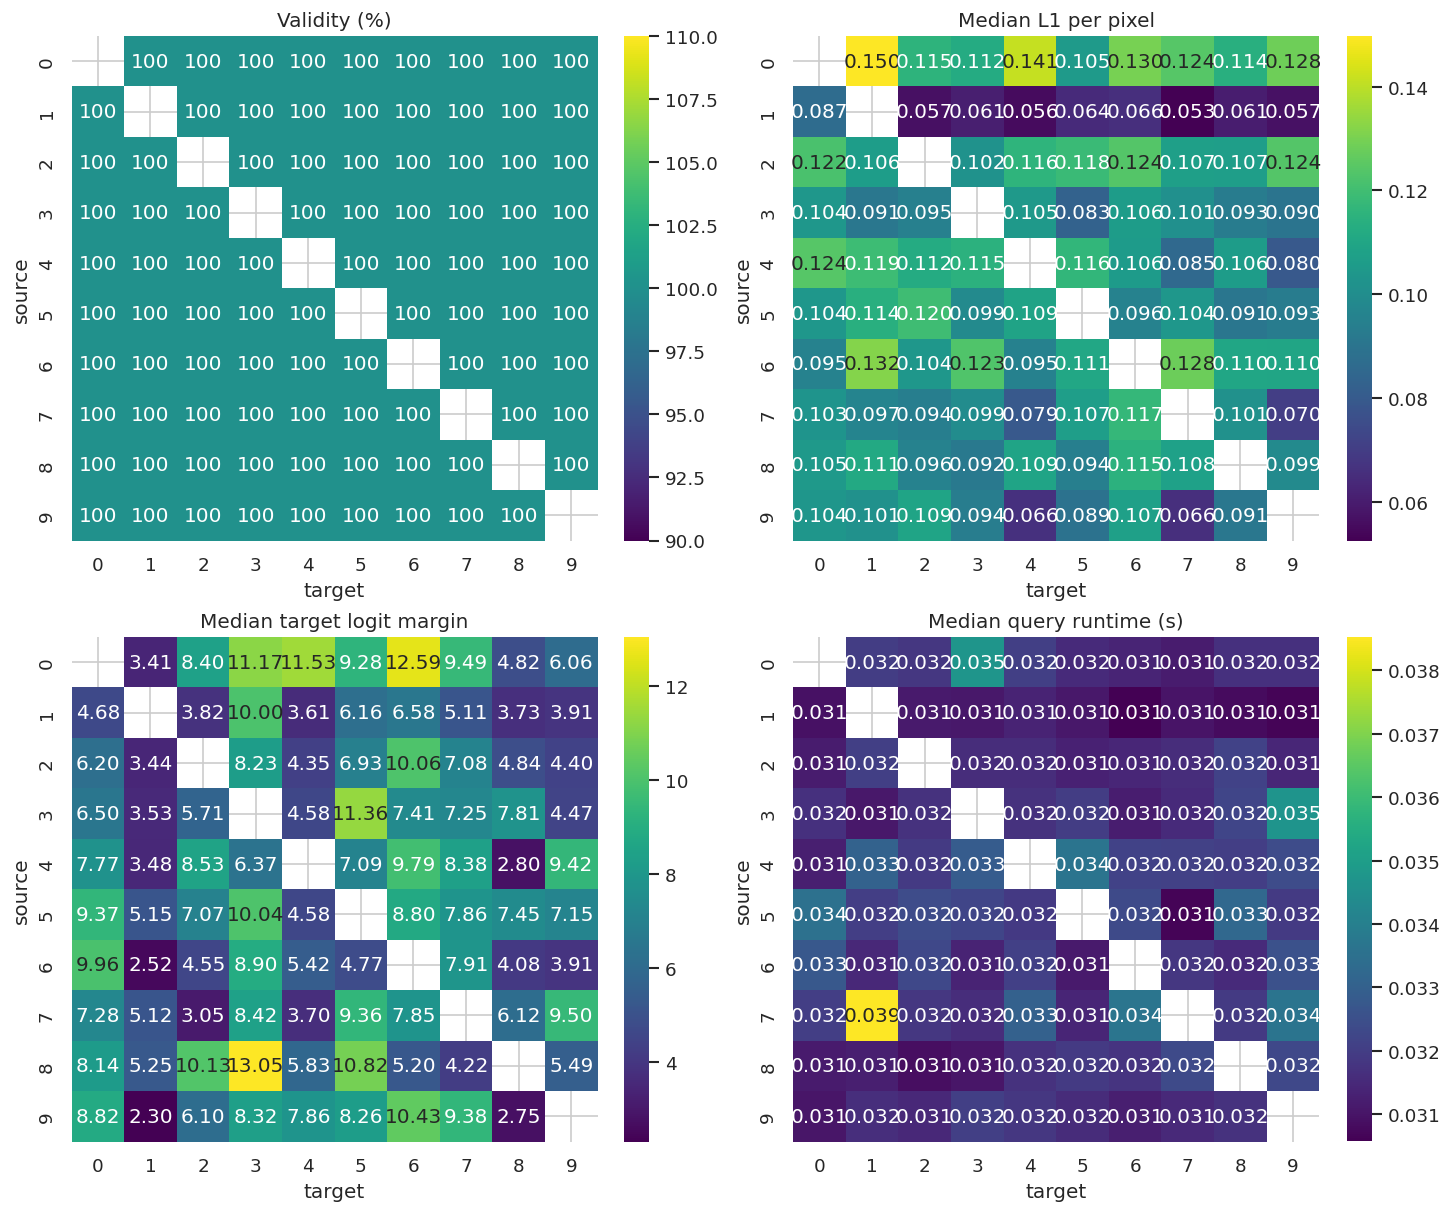

In [5]:
METRICS_DF = add_mnist_pixel_metrics(BENCHMARK_DF)
METRICS_DF = attach_target_confidence(METRICS_DF, CF_LOGITS)
METRICS_DF['success_numeric'] = METRICS_DF['success'].astype(float)

CORE_METRIC_LABELS = {
    'success_numeric': 'Validity ratio',
    'image_l1': 'L1',
    'image_l1_per_pixel': 'L1 / pixel',
    'image_l2': 'L2',
    'image_linf': 'Linf',
    'image_l0_count_1_over_255': 'L0 count (>1/255)',
    'image_l0_fraction_1_over_255': 'L0 fraction (>1/255)',
    'image_l0_count_0p01': 'L0 count (>0.01)',
    'image_l0_count_0p05': 'L0 count (>0.05)',
    'target_confidence': 'Target confidence',
    'target_logit_margin': 'Target logit margin',
    'runtime_s': 'Query runtime (s)',
}
CORE_SUMMARY_DF = clustered_metric_summary(
    METRICS_DF,
    CORE_METRIC_LABELS,
    n_resamples=BOOTSTRAP_RESAMPLES,
    seed=123,
)
CORE_SUMMARY_DF['label'] = CORE_SUMMARY_DF['metric'].map(CORE_METRIC_LABELS)
CORE_SUMMARY_DF = CORE_SUMMARY_DF[['metric', 'label', 'n', 'n_clusters', 'estimate', 'ci_low', 'ci_high', 'median', 'q25', 'q75']]
display(CORE_SUMMARY_DF.round(6))

VALIDITY_PAIR_DF = mnist_pair_metric_table(METRICS_DF, 'success_numeric', agg='mean', scale=100.0)
L1_PAIR_DF = mnist_pair_metric_table(METRICS_DF[METRICS_DF['success']], 'image_l1_per_pixel')
MARGIN_PAIR_DF = mnist_pair_metric_table(METRICS_DF[METRICS_DF['success']], 'target_logit_margin')
RUNTIME_PAIR_DF = mnist_pair_metric_table(METRICS_DF, 'runtime_s')

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
for ax, table, title, fmt in [
    (axes[0, 0], VALIDITY_PAIR_DF, 'Validity (%)', '.0f'),
    (axes[0, 1], L1_PAIR_DF, 'Median L1 per pixel', '.3f'),
    (axes[1, 0], MARGIN_PAIR_DF, 'Median target logit margin', '.2f'),
    (axes[1, 1], RUNTIME_PAIR_DF, 'Median query runtime (s)', '.3f'),
]:
    sns.heatmap(table, annot=True, fmt=fmt, cmap='viridis', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('target')
    ax.set_ylabel('source')
FIGURES['source_target_metrics'] = fig
plt.show()

## 4. Empirical robustness

Gaussian perturbations retain continuity with the tabular paper analysis. Uniform Linf perturbations are an additional image/CertCF diagnostic. Both are empirical tests around each returned CF—not formal certificates.

{'robustness_cache_hit': True}


,perturbation,level,mean_preservation_pct,all_preserved_pct,n_queries,n_source_images,n_samples,auc_norm
0,gaussian,0.00,100.0000,100.0,1000,120,64,0.9782
1,gaussian,0.01,99.7547,99.2,1000,120,64,0.9782
2,gaussian,0.03,99.5234,97.5,1000,120,64,0.9782
3,gaussian,0.05,99.1844,95.4,1000,120,64,0.9782
4,gaussian,0.10,98.2594,90.6,1000,120,64,0.9782
5,gaussian,0.20,94.7188,70.9,1000,120,64,0.9782
6,linf,0.00,100.0000,100.0,1000,120,64,0.9904
7,linf,0.01,99.8031,99.6,1000,120,64,0.9904
8,linf,0.03,99.6844,98.8,1000,120,64,0.9904
9,linf,0.05,99.5469,97.7,1000,120,64,0.9904


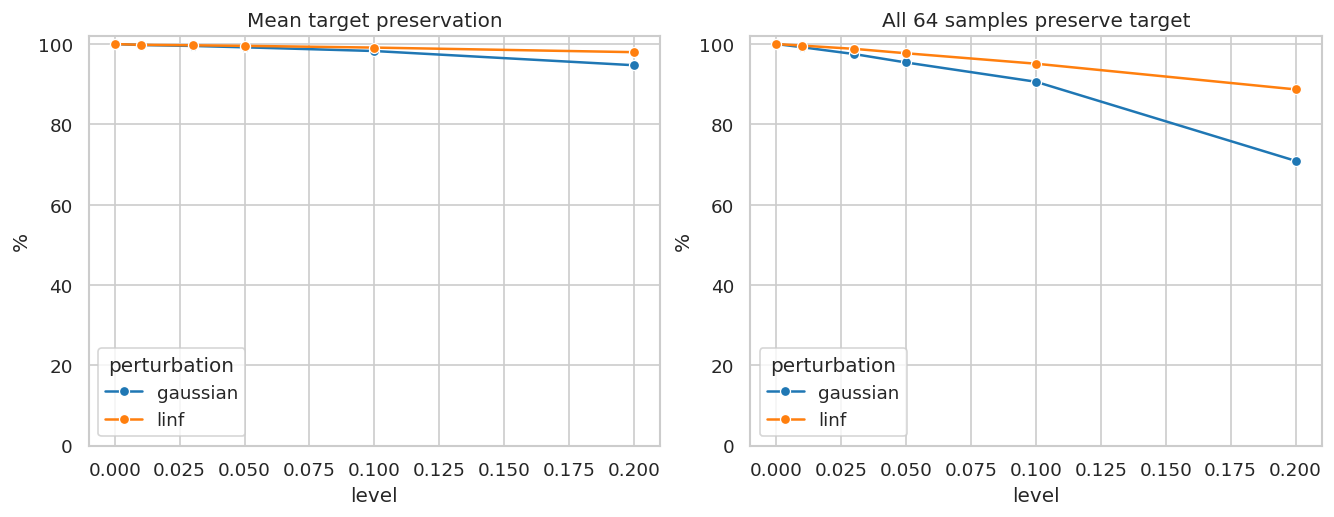

In [6]:
ROBUSTNESS_FINGERPRINT = cache_fingerprint(
    [RESULT_PATH, CHECKPOINT_PATH],
    settings={
        'levels': ROBUSTNESS_LEVELS,
        'n_samples': ROBUSTNESS_SAMPLES,
        'clip': True,
        'version': ANALYSIS_VERSION,
    },
)

def compute_robustness():
    frames = []
    for perturbation, seed in [('gaussian', 42), ('linf', 43)]:
        frames.append(evaluate_mnist_robustness(
            MODEL,
            X_CF,
            TARGETS,
            BENCHMARK_DF['query_idx'].to_numpy(),
            perturbation=perturbation,
            levels=ROBUSTNESS_LEVELS,
            n_samples=ROBUSTNESS_SAMPLES,
            seed=seed,
        ))
    return pd.concat(frames, ignore_index=True)

ROBUSTNESS_QUERY_DF, robustness_cache_hit = load_or_compute_dataframe(
    CACHE_DIR / 'robustness_per_query.parquet',
    ROBUSTNESS_FINGERPRINT,
    compute_robustness,
)
ROBUSTNESS_CURVE_DF = robustness_curve_summary(ROBUSTNESS_QUERY_DF)
print({'robustness_cache_hit': robustness_cache_hit})
display(ROBUSTNESS_CURVE_DF.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for ax, column, title in [
    (axes[0], 'mean_preservation_pct', 'Mean target preservation'),
    (axes[1], 'all_preserved_pct', f'All {ROBUSTNESS_SAMPLES} samples preserve target'),
]:
    sns.lineplot(data=ROBUSTNESS_CURVE_DF, x='level', y=column, hue='perturbation', marker='o', ax=ax)
    ax.set_ylim(0, 102)
    ax.set_ylabel('%')
    ax.set_title(title)
FIGURES['robustness_curves'] = fig
plt.show()

## 5. Plausibility and privacy

The reference population is the full deterministic 55k MNIST training split, matching the tabular notebooks. Ground-truth training labels define same-class neighborhoods. Pixel Manhattan results preserve paper continuity; Euclidean LeNet embeddings provide the image-specific view.

In [7]:
def combined_neighbor_frame(x_train, y_train, x_cf, targets, metric):
    reference, cf_metrics = same_class_neighbor_metrics(
        x_train, y_train, x_cf, targets, metric=metric
    )
    reference = reference.copy()
    reference['row_kind'] = 'train_reference'
    cf_metrics = cf_metrics.copy()
    cf_metrics['row_kind'] = 'counterfactual'
    cf_metrics['task_row'] = np.arange(len(cf_metrics))
    return pd.concat([reference, cf_metrics], ignore_index=True, sort=False)

PIXEL_NEIGHBOR_ALL_DF, pixel_neighbor_cache_hit = load_or_compute_dataframe(
    CACHE_DIR / 'pixel_same_class_neighbors.parquet',
    cache_fingerprint([RESULT_PATH], settings={'reference': 'full55k', 'metric': 'manhattan', 'clip': True, 'version': ANALYSIS_VERSION}),
    lambda: combined_neighbor_frame(X_TRAIN, Y_TRAIN, X_CF, TARGETS, 'manhattan'),
)
EMBED_NEIGHBOR_ALL_DF, embedding_neighbor_cache_hit = load_or_compute_dataframe(
    CACHE_DIR / 'embedding_same_class_neighbors.parquet',
    cache_fingerprint([RESULT_PATH, CHECKPOINT_PATH], settings={'reference': 'full55k', 'metric': 'euclidean', 'embedding': 84, 'version': ANALYSIS_VERSION}),
    lambda: combined_neighbor_frame(Z_TRAIN, Y_TRAIN, Z_CF, TARGETS, 'euclidean'),
)

def split_neighbor_frame(frame):
    reference = frame[frame['row_kind'].eq('train_reference')][['class_label', 'same_class_train_d1']].copy()
    cf_metrics = frame[frame['row_kind'].eq('counterfactual')].sort_values('task_row').reset_index(drop=True)
    return reference, cf_metrics

PIXEL_REFERENCE_DF, PIXEL_CF_NEIGHBOR_DF = split_neighbor_frame(PIXEL_NEIGHBOR_ALL_DF)
EMBED_REFERENCE_DF, EMBED_CF_NEIGHBOR_DF = split_neighbor_frame(EMBED_NEIGHBOR_ALL_DF)
PIXEL_RPR = relative_proximity_summary(PIXEL_REFERENCE_DF, PIXEL_CF_NEIGHBOR_DF)
EMBED_RPR = relative_proximity_summary(EMBED_REFERENCE_DF, EMBED_CF_NEIGHBOR_DF)
PIXEL_WASSERSTEIN_DF = same_class_distribution_summary(PIXEL_REFERENCE_DF, PIXEL_CF_NEIGHBOR_DF)
EMBED_WASSERSTEIN_DF = same_class_distribution_summary(EMBED_REFERENCE_DF, EMBED_CF_NEIGHBOR_DF)
print({'pixel_neighbor_cache_hit': pixel_neighbor_cache_hit, 'embedding_neighbor_cache_hit': embedding_neighbor_cache_hit})
display(pd.DataFrame([
    {'space': 'pixel Manhattan', **PIXEL_RPR, 'wasserstein_log1p_macro': PIXEL_WASSERSTEIN_DF['wasserstein_log1p'].mean()},
    {'space': 'LeNet embedding Euclidean', **EMBED_RPR, 'wasserstein_log1p_macro': EMBED_WASSERSTEIN_DF['wasserstein_log1p'].mean()},
]).round(5))

{'pixel_neighbor_cache_hit': True, 'embedding_neighbor_cache_hit': True}


,space,train_same_class_d1_mean,cf_same_class_d1_mean,rpr_pooled,rpr_class_macro,wasserstein_log1p_macro
0,pixel Manhattan,37.41672,3.55516,0.09502,0.09565,2.57343
1,LeNet embedding Euclidean,2.21956,0.48817,0.21994,0.22088,0.85316


In [8]:
def compute_embedding_privacy():
    local = neighborhood_label_metrics(Z_TRAIN, Y_TRAIN, Z_CF, TARGETS, k=20, metric='euclidean')
    local['embedding_lof'] = embedding_lof_scores(Z_TRAIN, Z_CF, n_neighbors=20)
    local['task_row'] = np.arange(len(local))
    return local

EMBED_PRIVACY_DF, embedding_privacy_cache_hit = load_or_compute_dataframe(
    CACHE_DIR / 'embedding_privacy.parquet',
    cache_fingerprint([RESULT_PATH, CHECKPOINT_PATH], settings={'reference': 'full55k', 'k': 20, 'embedding': 84, 'version': ANALYSIS_VERSION}),
    compute_embedding_privacy,
)
PRIVACY_TASK_DF = METRICS_DF[['query_idx', 'source_class', 'target_class']].copy()
for column in ['same_class_d1', 'same_class_d2', 'same_class_percentile', 'neighbor_contrast']:
    PRIVACY_TASK_DF[f'pixel_{column}'] = PIXEL_CF_NEIGHBOR_DF[column].to_numpy()
    PRIVACY_TASK_DF[f'embedding_{column}'] = EMBED_CF_NEIGHBOR_DF[column].to_numpy()
for column in ['knn_normalized_entropy', 'knn_target_purity', 'embedding_lof']:
    PRIVACY_TASK_DF[column] = EMBED_PRIVACY_DF.sort_values('task_row')[column].to_numpy()
PRIVACY_TASK_DF['exact_training_hit'] = PRIVACY_TASK_DF['pixel_same_class_d1'] <= 1e-6

PRIVACY_SUMMARY_DF = clustered_metric_summary(
    PRIVACY_TASK_DF,
    [
        'pixel_same_class_d1', 'pixel_same_class_percentile', 'pixel_neighbor_contrast',
        'embedding_same_class_d1', 'embedding_same_class_percentile', 'embedding_neighbor_contrast',
        'knn_normalized_entropy', 'knn_target_purity', 'embedding_lof', 'exact_training_hit',
    ],
    n_resamples=BOOTSTRAP_RESAMPLES,
    seed=400,
)
print({'embedding_privacy_cache_hit': embedding_privacy_cache_hit})
display(PRIVACY_SUMMARY_DF.round(5))
display(PIXEL_WASSERSTEIN_DF.round(5))
display(EMBED_WASSERSTEIN_DF.round(5))

{'embedding_privacy_cache_hit': True}


,metric,n,n_clusters,estimate,ci_low,ci_high,median,q25,q75
0,pixel_same_class_d1,1000,120,3.55516,2.93238,4.20702,1.23315,0.93088,2.29052
1,pixel_same_class_percentile,1000,120,0.02977,0.02068,0.03954,0.00000,0.00000,0.00000
2,pixel_neighbor_contrast,1000,120,0.07714,0.06665,0.08885,0.03845,0.02513,0.05823
3,embedding_same_class_d1,1000,120,0.48817,0.42489,0.55559,0.24181,0.14625,0.39348
4,embedding_same_class_percentile,1000,120,0.03879,0.02702,0.05114,0.00000,0.00000,0.00000
5,embedding_neighbor_contrast,1000,120,0.15652,0.14455,0.16855,0.09757,0.05450,0.17753
6,knn_normalized_entropy,1000,120,0.02623,0.02219,0.03051,0.00000,-0.00000,0.00000
7,knn_target_purity,1000,120,0.95535,0.94546,0.96452,1.00000,1.00000,1.00000
8,embedding_lof,1000,120,1.12400,1.11570,1.13238,1.08898,1.03509,1.18242
9,exact_training_hit,1000,120,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


,target_class,wasserstein_log1p,n_train,n_cf
0,0,2.73024,5441,103
1,1,1.84494,6190,99
2,2,2.83650,5477,101
3,3,2.78127,5600,99
4,4,2.77162,5346,100
5,5,2.60917,5000,100
6,6,2.41893,5422,94
7,7,2.32625,5710,105
8,8,2.95379,5347,101
9,9,2.46157,5467,98


,target_class,wasserstein_log1p,n_train,n_cf
0,0,0.86984,5441,103
1,1,0.60352,6190,99
2,2,1.01674,5477,101
3,3,0.93727,5600,99
4,4,0.89362,5346,100
5,5,0.89013,5000,100
6,6,0.70364,5422,94
7,7,0.80676,5710,105
8,8,0.96810,5347,101
9,9,0.84204,5467,98


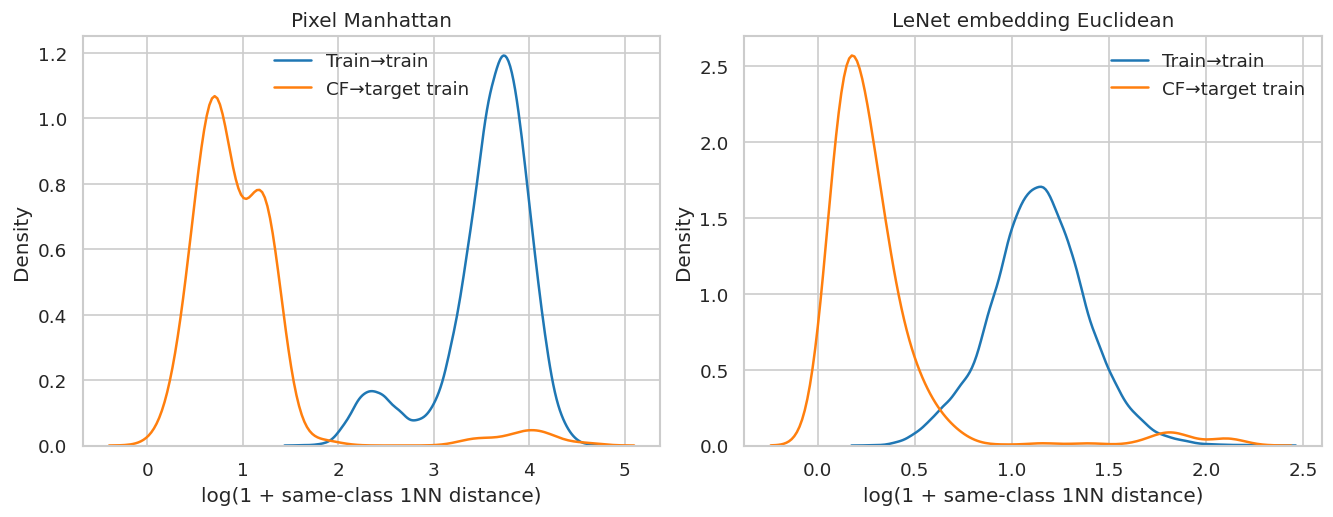

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for ax, reference, cf_metrics, title in [
    (axes[0], PIXEL_REFERENCE_DF, PIXEL_CF_NEIGHBOR_DF, 'Pixel Manhattan'),
    (axes[1], EMBED_REFERENCE_DF, EMBED_CF_NEIGHBOR_DF, 'LeNet embedding Euclidean'),
]:
    sns.kdeplot(np.log1p(reference['same_class_train_d1']), label='Train→train', ax=ax)
    sns.kdeplot(np.log1p(cf_metrics['same_class_d1']), label='CF→target train', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('log(1 + same-class 1NN distance)')
    ax.legend(frameon=False)
FIGURES['same_class_nn_distributions'] = fig
plt.show()

## 6. CertCF efficiency and implementation diagnostics

Pixel-wise redundancy is deliberately excluded: reverting one pixel at a time makes distributed image edits appear almost entirely redundant. The stored value remains available in the parquet but is not interpreted as an image metric.

In [10]:
TIMING_COLUMNS = [
    'runtime_s', 'meta__query_loop_time_ms', 'meta__search_time_ms',
    'meta__projection_time_ms', 'meta__total_time_ms',
]
TIMING_SUMMARY_DF = pd.DataFrame([
    {
        'metric': column,
        'mean': pd.to_numeric(BENCHMARK_DF[column], errors='coerce').mean(),
        'median': pd.to_numeric(BENCHMARK_DF[column], errors='coerce').median(),
        'q95': pd.to_numeric(BENCHMARK_DF[column], errors='coerce').quantile(0.95),
    }
    for column in TIMING_COLUMNS if column in BENCHMARK_DF
])
RESOURCE_SUMMARY_DF = pd.DataFrame([{
    'atlas_build_time_s': float(BENCHMARK_DF['build_time_s'].dropna().iloc[0]),
    'query_runtime_total_s': float(BENCHMARK_DF['runtime_s'].sum()),
    'ram_rss_start_mb': float(BENCHMARK_DF['method_meta__ram_rss_mb_start'].dropna().iloc[0]),
    'ram_rss_peak_mb': float(BENCHMARK_DF['method_meta__ram_rss_mb_peak'].dropna().iloc[0]),
    'query_batch_size': int(BENCHMARK_DF['method_meta__query_batch_size'].dropna().iloc[0]),
}])
SOLVER_STATUS_DF = (
    BENCHMARK_DF.groupby(['meta__cvxpy_solver_used', 'meta__cvxpy_solver_status', 'meta__cvxpy_fallback_used'])
    .size().rename('n_tasks').reset_index()
)
SEARCH_DIAGNOSTICS_DF = pd.DataFrame([{
    'solver_attempts_mean': BENCHMARK_DF['meta__cvxpy_solver_attempts'].mean(),
    'candidates_considered_mean': BENCHMARK_DF['meta__n_candidates_considered'].mean(),
    'candidates_pruned_top_k_mean': BENCHMARK_DF['meta__n_candidates_pruned_by_top_k'].mean(),
    'candidates_pruned_bound_mean': BENCHMARK_DF['meta__n_candidates_pruned_by_bound'].mean(),
    'nearest_anchor_distance_mean': BENCHMARK_DF['meta__nearest_anchor_initial_distance'].mean(),
    'nearest_anchor_fallback_pct': 100.0 * BENCHMARK_DF['meta__nearest_anchor_fallback_used'].mean(),
}])
display(RESOURCE_SUMMARY_DF.round(4))
display(TIMING_SUMMARY_DF.round(4))
display(SOLVER_STATUS_DF)
display(SEARCH_DIAGNOSTICS_DF.round(4))

,atlas_build_time_s,query_runtime_total_s,ram_rss_start_mb,ram_rss_peak_mb,query_batch_size
0,1741.6221,34.8313,1546.0078,3009.8906,1


,metric,mean,median,q95
0,runtime_s,0.0348,0.0317,0.0563
1,meta__query_loop_time_ms,34.7433,31.5681,56.2310
2,meta__search_time_ms,6.5348,6.0692,8.0568
3,meta__projection_time_ms,28.2085,25.4840,49.7172
4,meta__total_time_ms,34.7777,31.6040,56.2659


,meta__cvxpy_solver_used,meta__cvxpy_solver_status,meta__cvxpy_fallback_used,n_tasks
0,CLARABEL,optimal,False,1000


,solver_attempts_mean,candidates_considered_mean,candidates_pruned_top_k_mean,candidates_pruned_bound_mean,nearest_anchor_distance_mean,nearest_anchor_fallback_pct
0,1.0,1.058,994.798,1.942,81.8408,0.0


## 7. Qualitative examples

For each source digit, the successful task with the smallest and largest clipped L1 distance is shown. These are descriptive extremes, not randomly selected examples.

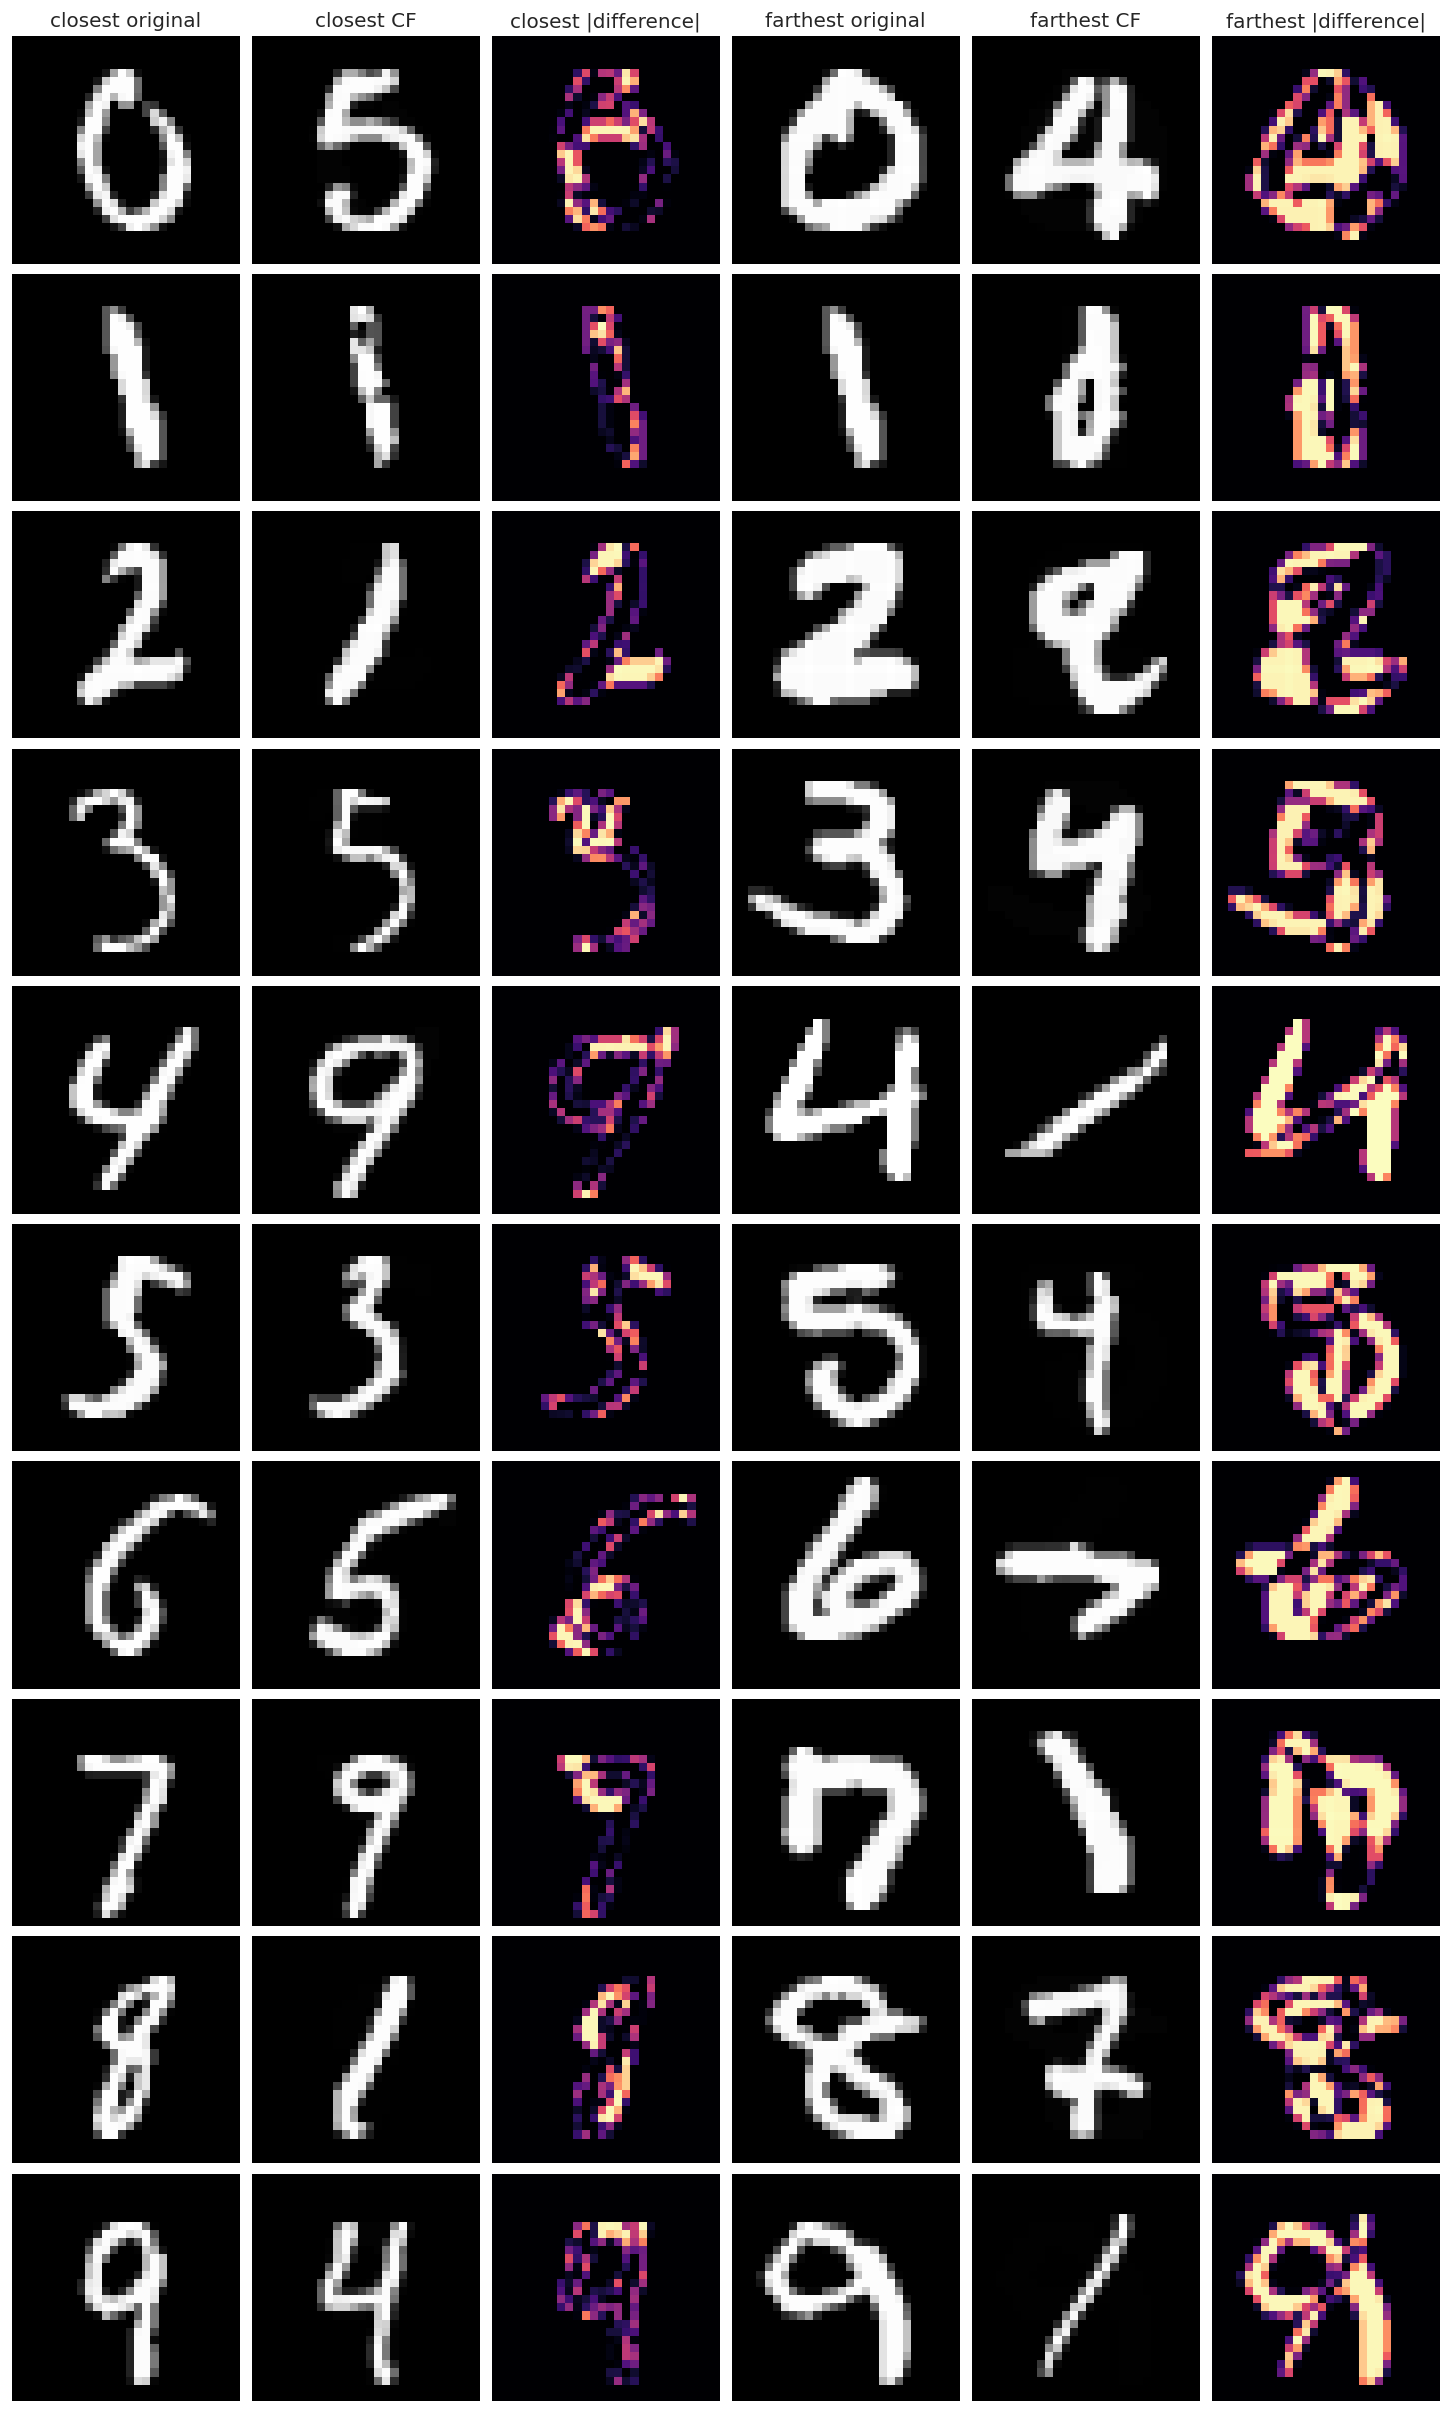

In [11]:
successful = METRICS_DF[METRICS_DF['success']].copy()
closest_idx = successful.groupby('source_class')['image_l1'].idxmin()
farthest_idx = successful.groupby('source_class')['image_l1'].idxmax()
fig, axes = plt.subplots(10, 6, figsize=(12, 20), constrained_layout=True)
for row, source_class in enumerate(range(10)):
    selected = [successful.loc[closest_idx.loc[source_class]], successful.loc[farthest_idx.loc[source_class]]]
    for block, record in enumerate(selected):
        task_row = int(record.name)
        original = X_ORIG[task_row].reshape(28, 28)
        counterfactual = X_CF[task_row].reshape(28, 28)
        difference = np.abs(counterfactual - original)
        for offset, image, cmap, label in [
            (0, original, 'gray', 'original'),
            (1, counterfactual, 'gray', 'CF'),
            (2, difference, 'magma', '|difference|'),
        ]:
            ax = axes[row, 3 * block + offset]
            ax.imshow(image, cmap=cmap, vmin=0, vmax=1)
            if row == 0:
                ax.set_title(('closest ' if block == 0 else 'farthest ') + label)
            ax.axis('off')
        axes[row, 3 * block + 1].set_ylabel(
            f"{int(record.source_class)}→{int(record.target_class)}\nL1={record.image_l1:.1f}\np={record.target_confidence:.3f}",
            rotation=0, labelpad=34, va='center', fontsize=8,
        )
FIGURES['qualitative_extremes'] = fig
plt.show()

## 8. Final tables and optional export

In [12]:
BY_SOURCE_DF = (
    METRICS_DF.groupby('source_class')
    .agg(n_tasks=('success', 'size'), validity_pct=('success', lambda s: 100*s.mean()), median_l1=('image_l1', 'median'), median_l1_per_pixel=('image_l1_per_pixel', 'median'), median_margin=('target_logit_margin', 'median'), median_runtime_s=('runtime_s', 'median'))
    .reset_index()
)
BY_TARGET_DF = (
    METRICS_DF.groupby('target_class')
    .agg(n_tasks=('success', 'size'), validity_pct=('success', lambda s: 100*s.mean()), median_l1=('image_l1', 'median'), median_l1_per_pixel=('image_l1_per_pixel', 'median'), median_margin=('target_logit_margin', 'median'), median_runtime_s=('runtime_s', 'median'))
    .reset_index()
)
BY_PAIR_DF = (
    METRICS_DF.groupby(['source_class', 'target_class'])
    .agg(n_tasks=('success', 'size'), validity_pct=('success', lambda s: 100*s.mean()), median_l1=('image_l1', 'median'), median_l1_per_pixel=('image_l1_per_pixel', 'median'), median_margin=('target_logit_margin', 'median'), median_runtime_s=('runtime_s', 'median'))
    .reset_index()
)
display(BY_SOURCE_DF.round(4))
display(BY_TARGET_DF.round(4))
display(BY_PAIR_DF.round(4))

if EXPORT_OUTPUTS:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    tables = {
        'run_audit': AUDIT_DF,
        'core_metrics': CORE_SUMMARY_DF,
        'by_source': BY_SOURCE_DF,
        'by_target': BY_TARGET_DF,
        'by_source_target': BY_PAIR_DF,
        'robustness': ROBUSTNESS_CURVE_DF,
        'privacy': PRIVACY_SUMMARY_DF,
        'pixel_wasserstein': PIXEL_WASSERSTEIN_DF,
        'embedding_wasserstein': EMBED_WASSERSTEIN_DF,
        'resources': RESOURCE_SUMMARY_DF,
        'timings': TIMING_SUMMARY_DF,
        'solver_status': SOLVER_STATUS_DF,
    }
    for name, table in tables.items():
        table.to_csv(EXPORT_DIR / f'{name}.csv', index=False)
        table.to_latex(EXPORT_DIR / f'{name}.tex', index=False, float_format='%.5f')
    for name, fig in FIGURES.items():
        fig.savefig(EXPORT_DIR / f'{name}.png', dpi=200, bbox_inches='tight')
        fig.savefig(EXPORT_DIR / f'{name}.pdf', bbox_inches='tight')
    print(f'Exported tables and figures to {EXPORT_DIR}')
else:
    print('EXPORT_OUTPUTS=False; analysis caches were maintained, final artifacts were not exported.')

,source_class,n_tasks,validity_pct,median_l1,median_l1_per_pixel,median_margin,median_runtime_s
0,0,100,100.0,93.804497,0.1196,7.7169,0.0316
1,1,100,100.0,48.002399,0.0612,4.7174,0.0310
2,2,100,100.0,90.060600,0.1149,6.3622,0.0315
3,3,100,100.0,75.027702,0.0957,5.9511,0.0318
4,4,100,100.0,86.232498,0.1100,7.2301,0.0323
5,5,100,100.0,82.311798,0.1050,7.4583,0.0323
6,6,100,100.0,85.331100,0.1088,5.4499,0.0317
7,7,100,100.0,76.106598,0.0971,6.6582,0.0325
8,8,100,100.0,77.369598,0.0987,7.1242,0.0315
9,9,100,100.0,73.504501,0.0938,7.5421,0.0316


,target_class,n_tasks,validity_pct,median_l1,median_l1_per_pixel,median_margin,median_runtime_s
0,0,103,100.0,81.828300,0.1044,7.2692,0.0313
1,1,99,100.0,89.868500,0.1146,3.4391,0.0320
2,2,101,100.0,81.920898,0.1045,5.2104,0.0317
3,3,99,100.0,76.809601,0.0980,8.9340,0.0317
4,4,100,100.0,77.915001,0.0994,5.2965,0.0319
5,5,100,100.0,75.924896,0.0968,8.0125,0.0315
6,6,94,100.0,83.731796,0.1068,7.5279,0.0314
7,7,105,100.0,77.912201,0.0994,7.3684,0.0315
8,8,101,100.0,76.176201,0.0972,4.6055,0.0318
9,9,98,100.0,73.999496,0.0944,6.1060,0.0318


,source_class,target_class,n_tasks,validity_pct,median_l1,median_l1_per_pixel,median_margin,median_runtime_s
0,0,1,11,100.0,117.387703,0.1497,3.4146,0.0320
1,0,2,12,100.0,90.331703,0.1152,8.3976,0.0318
2,0,3,10,100.0,87.934998,0.1122,11.1683,0.0347
3,0,4,12,100.0,110.720398,0.1412,11.5328,0.0321
4,0,5,11,100.0,82.451599,0.1052,9.2835,0.0315
...,...,...,...,...,...,...,...,...
85,9,4,10,100.0,51.808701,0.0661,7.8632,0.0318
86,9,5,11,100.0,69.939201,0.0892,8.2577,0.0316
87,9,6,9,100.0,84.131104,0.1073,10.4302,0.0312
88,9,7,12,100.0,51.618500,0.0658,9.3775,0.0315


EXPORT_OUTPUTS=False; analysis caches were maintained, final artifacts were not exported.
